Berkeley Earth:
     0   1      2      3   4   5   6   7   8   9   10  11
0  1850   1 -0.753  0.365 NaN NaN NaN NaN NaN NaN NaN NaN
1  1850   2 -0.202  0.416 NaN NaN NaN NaN NaN NaN NaN NaN
2  1850   3 -0.367  0.373 NaN NaN NaN NaN NaN NaN NaN NaN
3  1850   4 -0.596  0.324 NaN NaN NaN NaN NaN NaN NaN NaN
4  1850   5 -0.619  0.267 NaN NaN NaN NaN NaN NaN NaN NaN
(4200, 12)

CO2:
   year  month   decimal  average  average_unc   trend  trend_unc
0  1979      1  1979.042   336.56         0.11  335.92       0.09
1  1979      2  1979.125   337.29         0.09  336.26       0.09
2  1979      3  1979.208   337.88         0.11  336.51       0.09
3  1979      4  1979.292   338.32         0.13  336.72       0.10
4  1979      5  1979.375   338.26         0.04  336.71       0.10
Index(['year', 'month', 'decimal', 'average', 'average_unc', 'trend',
       'trend_unc'],
      dtype='str')

CH4:
   year     mean   unc
0  1984  1644.84  0.71
1  1985  1657.29  0.66
2  1986  1670.09  0.79
3  1987  1682.7

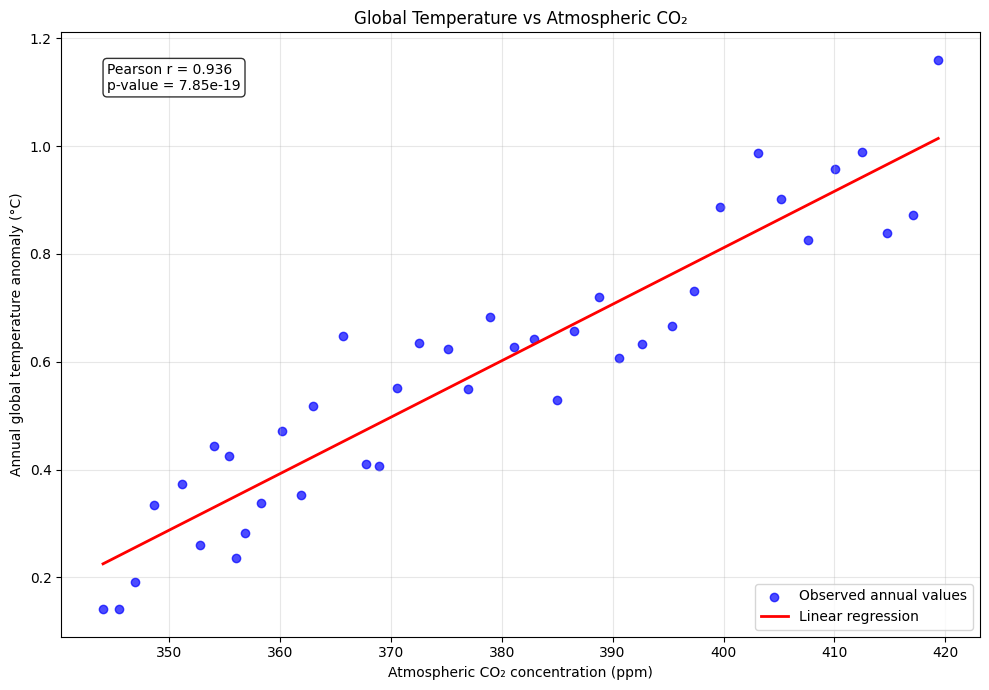

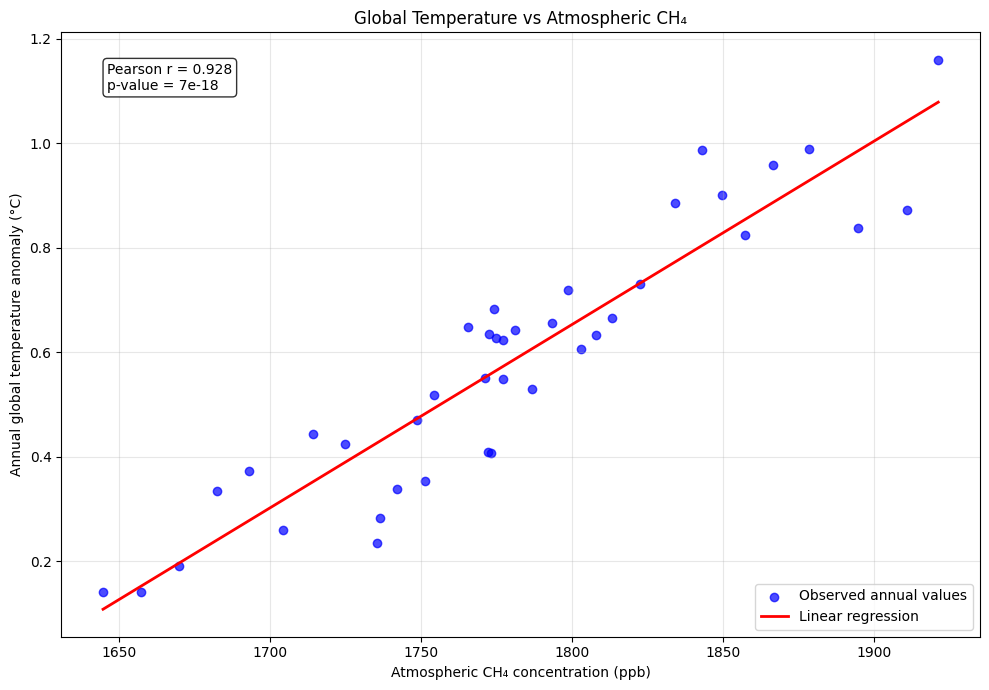

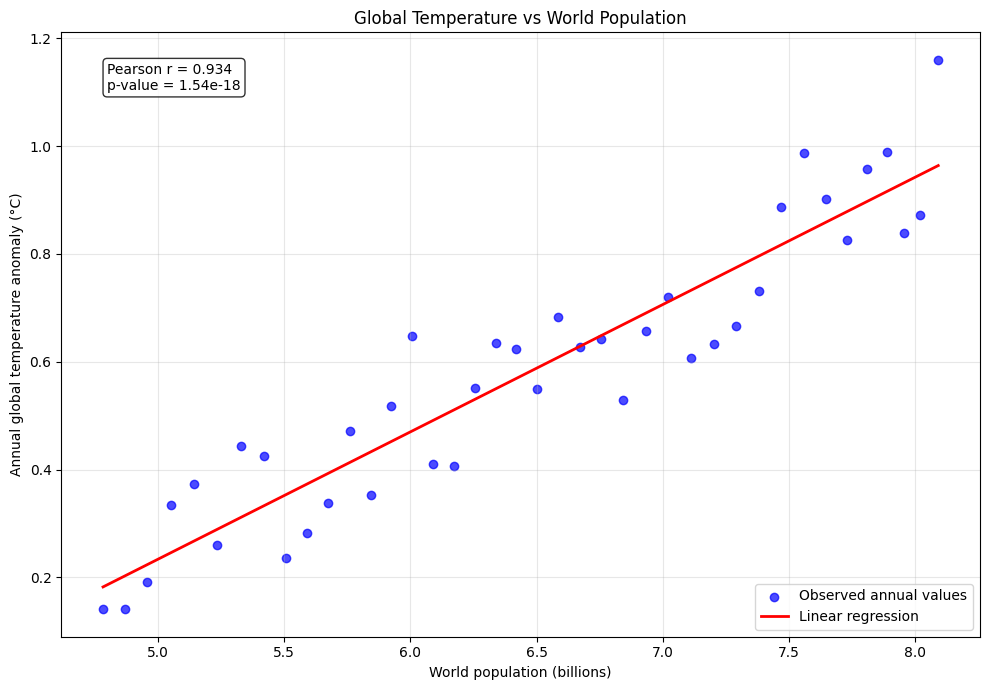


Saved:
- harmonised_temperature_CO2_CH4_population.csv
- correlation_results.csv


In [27]:

# ============================================================
# Correlation between global temperature, CO2, CH4 and population
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from urllib.request import urlopen
from urllib.parse import urljoin
from io import StringIO


# ------------------------------------------------------------
# 1. DATA SOURCES
# ------------------------------------------------------------

# Berkeley Earth: Global Land + Ocean temperature
TEMP_URL = (
    "https://berkeley-earth-temperature.s3.us-west-1.amazonaws.com/"
    "Global/Land_and_Ocean_complete.txt"
)

# NOAA Global Monitoring Laboratory - global atmospheric CO2
CO2_CSV_URL = (
    "https://gml.noaa.gov/webdata/ccgg/trends/"
    "co2/co2_mm_gl.csv"
)

# NOAA Global Monitoring Laboratory - global atmospheric CH4
CH4_PAGE_URL = "https://gml.noaa.gov/ccgg/trends_ch4/"

# Our World in Data - UN World Population Prospects 2024
POP_CSV_URL = (
    "https://ourworldindata.org/grapher/"
    "population-unwpp.csv"
)


# ------------------------------------------------------------
# 2. DOWNLOAD BERKELEY EARTH TEMPERATURE DATA
# ------------------------------------------------------------

temp_raw = pd.read_csv(
    TEMP_URL,
    comment="%",
    sep=r"\s+",
    header=None
)

print("Berkeley Earth:")
print(temp_raw.head())
print(temp_raw.shape)


# ------------------------------------------------------------
# 3. READ BERKELEY EARTH DATA
# ------------------------------------------------------------

temp = temp_raw.iloc[:, :4].copy()

temp.columns = [
    "year",
    "month",
    "temperature",
    "uncertainty"
]

temp = temp.dropna(
    subset=["year", "month", "temperature"]
)

temp["year"] = pd.to_numeric(
    temp["year"],
    errors="coerce"
)

temp["month"] = pd.to_numeric(
    temp["month"],
    errors="coerce"
)

temp["temperature"] = pd.to_numeric(
    temp["temperature"],
    errors="coerce"
)

# Keep valid monthly observations
temp = temp[
    (temp["year"] >= 1850) &
    (temp["month"] >= 1) &
    (temp["month"] <= 12)
]


# ------------------------------------------------------------
# 4. CALCULATE ANNUAL TEMPERATURE
# ------------------------------------------------------------

temp_annual = (
    temp.groupby("year")["temperature"]
    .mean()
    .reset_index()
)

temp_annual.columns = [
    "year",
    "temperature"
]


# ------------------------------------------------------------
# 5. CO2
# ------------------------------------------------------------

# Download CO2 data using urllib instead of requests

with urlopen(CO2_CSV_URL, timeout=60) as response:
    co2_text = response.read().decode("utf-8")

co2_raw = pd.read_csv(
    StringIO(co2_text),
    comment="#"
)

print("\nCO2:")
print(co2_raw.head())
print(co2_raw.columns)


# Select relevant columns
co2 = co2_raw.rename(
    columns={
        "average": "co2"
    }
)

co2["year"] = pd.to_numeric(
    co2["year"],
    errors="coerce"
)

co2["co2"] = pd.to_numeric(
    co2["co2"],
    errors="coerce"
)

co2 = co2.dropna(
    subset=["year", "co2"]
)


# Calculate annual mean CO2 concentration
co2_annual = (
    co2.groupby("year")["co2"]
    .mean()
    .reset_index()
)

# ------------------------------------------------------------
# 6. CH4 - NOAA GLOBAL ATMOSPHERIC METHANE
# ------------------------------------------------------------

# NOAA GML provides the globally averaged annual CH4 dataset
# directly as a CSV file.

CH4_CSV_URL = (
    "https://gml.noaa.gov/webdata/ccgg/trends/"
    "ch4/ch4_annmean_gl.csv"
)

ch4_raw = pd.read_csv(
    CH4_CSV_URL,
    comment="#"
)

print("\nCH4:")
print(ch4_raw.head())
print(ch4_raw.columns.tolist())



# ------------------------------------------------------------
# 6B. IDENTIFY CH4 YEAR AND CONCENTRATION COLUMNS
# ------------------------------------------------------------

# Print columns so you can verify the NOAA file structure

print("\nCH4 columns found:")
print(ch4_raw.columns.tolist())


# Try to identify the year column
year_column = None

for col in ch4_raw.columns:

    if col.lower().strip() in [
        "year",
        "yr"
    ]:
        year_column = col
        break


# Try to identify the annual mean CH4 column
ch4_column = None

for col in ch4_raw.columns:

    col_lower = col.lower()

    if (
        "average" in col_lower
        or "mean" in col_lower
        or "ch4" in col_lower
    ):
        if col != year_column:
            ch4_column = col
            break


if year_column is None:
    raise ValueError(
        "Could not identify the year column in the CH4 dataset."
    )

if ch4_column is None:
    raise ValueError(
        "Could not identify the CH4 concentration column."
    )


print("\nUsing CH4 year column:")
print(year_column)

print("\nUsing CH4 concentration column:")
print(ch4_column)


# Rename columns
ch4 = ch4_raw.rename(
    columns={
        year_column: "year",
        ch4_column: "ch4"
    }
)

ch4["year"] = pd.to_numeric(
    ch4["year"],
    errors="coerce"
)

ch4["ch4"] = pd.to_numeric(
    ch4["ch4"],
    errors="coerce"
)

ch4 = ch4.dropna(
    subset=["year", "ch4"]
)


# Annual CH4 data
ch4_annual = (
    ch4.groupby("year")["ch4"]
    .mean()
    .reset_index()
)


# ------------------------------------------------------------
# 7. WORLD POPULATION
# ------------------------------------------------------------

# UN World Population Prospects 2024 dataset
# Convenient CSV provided by Our World in Data.
# The data are read directly from the URL.
# Nothing is downloaded or stored locally.

from urllib.request import Request, urlopen
from io import StringIO

POP_CSV_URL = (
    "https://ourworldindata.org/grapher/"
    "population-unwpp.csv"
)

# Read directly from URL
request = Request(
    POP_CSV_URL,
    headers={
        "User-Agent": "Mozilla/5.0"
    }
)

with urlopen(request) as response:
    population_raw = pd.read_csv(
        StringIO(response.read().decode("utf-8"))
    )

print("\nPopulation:")
print(population_raw.head())
print("\nPopulation columns:")
print(population_raw.columns.tolist())


# ------------------------------------------------------------
# Keep the global population
# ------------------------------------------------------------

population = population_raw[
    population_raw["Code"] == "OWID_WRL"
].copy()


# The OWID grapher CSV contains:
# "Year" = year
# The remaining column is the population value.
#
# Find the population column automatically instead of
# depending on its exact long name.

population_column = [
    col for col in population.columns
    if "population" in col.lower()
][0]


population = population.rename(
    columns={
        "Year": "year",
        population_column: "population"
    }
)


population = population[
    ["year", "population"]
]


population["year"] = pd.to_numeric(
    population["year"],
    errors="coerce"
)

population["population"] = pd.to_numeric(
    population["population"],
    errors="coerce"
)

population = population.dropna()


print("\nProcessed population data:")
print(population.head())
print(population.tail())




# ------------------------------------------------------------
# 8. HARMONISE THE DATASETS
# ------------------------------------------------------------

# All datasets are converted to annual values.
# The datasets are then merged using year as the common
# time unit.

data = temp_annual.merge(
    co2_annual,
    on="year",
    how="inner"
)

data = data.merge(
    ch4_annual,
    on="year",
    how="inner"
)

data = data.merge(
    population,
    on="year",
    how="inner"
)

# Sort chronologically
data = data.sort_values("year")

# Remove incomplete observations
data = data.dropna(
    subset=[
        "temperature",
        "co2",
        "ch4",
        "population"
    ]
)

print("\nHarmonised dataset:")
print(data.head())
print(data.tail())

print("\nCommon period:")
print(
    data["year"].min(),
    "to",
    data["year"].max()
)

print(
    "\nNumber of annual observations:",
    len(data)
)


# ------------------------------------------------------------
# 9. PEARSON CORRELATIONS
# ------------------------------------------------------------

variables = {
    "Atmospheric CO₂ concentration": "co2",
    "Atmospheric CH₄ concentration": "ch4",
    "World population": "population"
}

results = []

for name, column in variables.items():

    r, p = pearsonr(
        data["temperature"],
        data[column]
    )

    results.append(
        {
            "Variable": name,
            "Pearson r": r,
            "p-value": p,
            "N": len(data)
        }
    )


results_df = pd.DataFrame(results)

print("\n==========================================")
print("PEARSON CORRELATIONS")
print("==========================================")

print(
    results_df.to_string(
        index=False,
        float_format=lambda x: f"{x:.4f}"
    )
)


# ------------------------------------------------------------
# 10. CORRELATION PLOTS
# ------------------------------------------------------------

# Create one separate figure for each variable.
#
# Blue dots = observed annual values
# Red line = linear regression
#
# Each point represents ONE YEAR after the datasets
# have been harmonised to annual values.

for name, column in variables.items():

    # --------------------------------------------------------
    # Pearson correlation
    # --------------------------------------------------------

    r, p = pearsonr(
        data["temperature"],
        data[column]
    )


    # --------------------------------------------------------
    # Prepare x-axis
    # --------------------------------------------------------

    if column == "population":

        x_data = data[column] / 1e9
        x_label = "World population (billions)"
        title = "Global Temperature vs World Population"

    elif column == "co2":

        x_data = data[column]
        x_label = "Atmospheric CO₂ concentration (ppm)"
        title = "Global Temperature vs Atmospheric CO₂"

    elif column == "ch4":

        x_data = data[column]
        x_label = "Atmospheric CH₄ concentration (ppb)"
        title = "Global Temperature vs Atmospheric CH₄"


    # --------------------------------------------------------
    # Linear regression
    # --------------------------------------------------------

    slope, intercept = np.polyfit(
        x_data,
        data["temperature"],
        1
    )

    x = np.linspace(
        x_data.min(),
        x_data.max(),
        100
    )

    y = slope * x + intercept


    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(10, 7)
    )


    # --------------------------------------------------------
    # Scatter plot
    # --------------------------------------------------------

    ax.scatter(
        x_data,
        data["temperature"],
        color="blue",
        alpha=0.7,
        label="Observed annual values"
    )


    # --------------------------------------------------------
    # Regression line
    # --------------------------------------------------------

    ax.plot(
        x,
        y,
        color="red",
        linewidth=2,
        label="Linear regression"
    )


    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------

    ax.set_xlabel(
        x_label
    )

    ax.set_ylabel(
        "Annual global temperature anomaly (°C)"
    )

    ax.set_title(
        title
    )


    # --------------------------------------------------------
    # Pearson r and p-value
    # --------------------------------------------------------

    ax.text(
        0.05,
        0.95,
        f"Pearson r = {r:.3f}\n"
        f"p-value = {p:.3g}",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.8
        )
    )


    # --------------------------------------------------------
    # Legend
    # --------------------------------------------------------

    ax.legend(
        loc="best",
        frameon=True
    )


    # --------------------------------------------------------
    # Grid
    # --------------------------------------------------------

    ax.grid(
        alpha=0.3
    )


    # --------------------------------------------------------
    # Layout
    # --------------------------------------------------------

    plt.tight_layout()

    plt.show()


# ------------------------------------------------------------
# 11. SAVE DATA
# ------------------------------------------------------------

data.to_csv(
    "harmonised_temperature_CO2_CH4_population.csv",
    index=False
)

results_df.to_csv(
    "correlation_results.csv",
    index=False
)

print(
    "\nSaved:"
    "\n- harmonised_temperature_CO2_CH4_population.csv"
    "\n- correlation_results.csv"
)
